

# Nama : Muhamad Farrel Dava Fauzan




# Artificial Neural Network (ANN)

# Import Library

In [ ]:
# Import Libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf

from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report

import warnings
warnings.filterwarnings("ignore")

# Loading Dataset and Feature Engineering

In [ ]:
# Clear session & set seed
tf.keras.backend.clear_session()
np.random.seed(42)
tf.random.set_seed(42)

# Load Dataset
data = pd.read_csv("https://raw.githubusercontent.com/farrelfz/dataset-ppkd-2026/refs/heads/main/employee_attrition_preprocessed.csv")
data.head()


,Attrition,Age,DistanceFromHome,Education,EnvironmentSatisfaction,JobInvolvement,JobSatisfaction,MonthlyIncome,NumCompaniesWorked,PercentSalaryHike,...,MaritalStatus_Single,OverTime_Yes,JobRole_Human Resources,JobRole_Laboratory Technician,JobRole_Manager,JobRole_Manufacturing Director,JobRole_Research Director,JobRole_Research Scientist,JobRole_Sales Executive,JobRole_Sales Representative
0,1,41,1,2,2,3,4,5993,8,11,...,1,1,0,0,0,0,0,0,1,0
1,0,49,8,1,3,2,2,5130,1,23,...,0,0,0,0,0,0,0,1,0,0
2,1,37,2,2,4,2,3,2090,6,15,...,1,1,0,1,0,0,0,0,0,0
3,0,33,3,4,4,3,3,2909,1,11,...,0,1,0,0,0,0,0,1,0,0
4,0,27,2,1,1,3,2,3468,9,12,...,0,0,0,1,0,0,0,0,0,0


In [ ]:
data.shape

(1470, 38)

## Check Missing Values


In [ ]:
data.isnull().sum()

,0
Attrition,0
Age,0
DistanceFromHome,0
Education,0
EnvironmentSatisfaction,0
JobInvolvement,0
JobSatisfaction,0
MonthlyIncome,0
NumCompaniesWorked,0
PercentSalaryHike,0


## Data Splitting

In [ ]:
# Splitting between X and y

X = data.drop('Attrition', axis=1)
y = data["Attrition"]

In [ ]:
X_train_val, X_test, y_train_val, y_test = train_test_split(
    X, y,
    test_size=0.15,
    random_state=42
    )

X_train, X_val, y_train, y_val = train_test_split(
    X_train_val, y_train_val,
    test_size=0.2,
    random_state=42
    )

print(f'Shape of X_train: {X_train.shape}')
print(f'Shape of X_val: {X_val.shape}')
print(f'Shape of X_test: {X_test.shape}')

Shape of X_train: (999, 37)
Shape of X_val: (250, 37)
Shape of X_test: (221, 37)


## Scaler

In [ ]:
scaler = StandardScaler()
scaler.fit(X_train)

X_train = scaler.fit_transform(X_train)
X_val = scaler.transform(X_val)
X_test = scaler.transform(X_test)

print('Train Size : ', X_train.shape)
print('Val Size   : ', X_val.shape)
print('Test Size  : ', X_test.shape)

Train Size :  (999, 37)
Val Size   :  (250, 37)
Test Size  :  (221, 37)


# Handling Imbalance

In [ ]:
from sklearn.utils.class_weight import compute_class_weight
import numpy as np

classes = np.unique(y_train)

class_weights = compute_class_weight(
    class_weight='balanced',
    classes=classes,
    y=y_train
)

class_weight_dict = dict(
    zip(classes, class_weights)
)

print("Class Weight:", class_weight_dict)

Class Weight: {np.int64(0): np.float64(0.6003605769230769), np.int64(1): np.float64(2.9910179640718564)}


# Model Sequential API

In [ ]:
# Clear session
import tensorflow as tf

seed = 20
tf.keras.backend.clear_session()
np.random.seed(seed)
tf.random.set_seed(seed)

# Check TensorFlow version
print(tf.__version__)

2.20.0


In [ ]:
# Create Sequential API

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

model = Sequential()
model.add(Dense(64,
                activation='relu',
                kernel_initializer=tf.keras.initializers.HeNormal(seed),
                input_shape=(37,)))
model.add(Dense(32,
                activation='relu',
                kernel_initializer=tf.keras.initializers.HeNormal(seed)))
model.add(Dense(16,
                activation='relu',
                kernel_initializer=tf.keras.initializers.HeNormal(seed)))
model.add(Dense(8,
                activation='relu',
                kernel_initializer=tf.keras.initializers.HeNormal(seed)))

model.add(Dense(1,
                activation='sigmoid',
                kernel_initializer=tf.keras.initializers.GlorotNormal(seed)))

## Mengapa Memilih 64 Neuron di Lapisan Dense Pertama?

Pilihan jumlah neuron di lapisan `Dense` pertama, terutama 64, adalah kombinasi dari beberapa faktor dan praktik umum dalam membangun jaringan saraf:

1.  **Kapasitas Model (Representational Power)**:
    *   Lapisan pertama bertanggung jawab untuk mengekstraksi fitur-fitur awal dari data input Anda (37 fitur). Memilih jumlah neuron yang cukup besar (seperti 64) memberikan model 'kapasitas' yang memadai untuk menangkap berbagai pola dan hubungan kompleks yang mungkin ada dalam 37 fitur tersebut.
    *   Jika jumlah neuron terlalu kecil, model mungkin tidak memiliki kapasitas yang cukup untuk mempelajari representasi yang bermakna, sehingga menyebabkan *underfitting* (kinerja buruk baik pada data latih maupun data baru).

2.  **Praktik Umum dan 'Rule of Thumb'**:
    *   Angka 64 adalah kelipatan dari 2, dan seringkali merupakan kelipatan dari 16 atau 32. Dalam desain jaringan saraf, seringkali digunakan jumlah neuron yang merupakan pangkat dari 2 (misalnya, 32, 64, 128, 256, 512). Ini bukan aturan keras, tetapi seringkali bekerja dengan baik dalam praktik dan mungkin juga memiliki efisiensi komputasi tertentu pada beberapa *hardware*.
    *   Memulai dengan jumlah yang relatif besar seperti 64 atau 128 untuk lapisan pertama adalah titik awal yang wajar sebelum mengurangi jumlah neuron di lapisan berikutnya.

3.  **Hubungan dengan Ukuran Input**:
    *   Dengan 37 fitur input, memilih 64 neuron di lapisan pertama berarti lapisan ini memiliki lebih banyak neuron daripada fitur input. Ini memungkinkan model untuk 'memperluas' dimensi fitur dan menciptakan representasi yang lebih kaya dari input asli.

4.  **Menghindari Terlalu Kecil atau Terlalu Besar**:
    *   **Mengapa tidak lebih kecil (misal 8 atau 16)?** Jumlah neuron yang terlalu kecil di lapisan pertama mungkin membatasi kemampuan model untuk mempelajari fitur-fitur penting sejak awal. Ini bisa menyebabkan *bottleneck* informasi yang terlalu ketat terlalu dini dalam jaringan.
    *   **Mengapa tidak lebih besar (misal 128 atau 256)?** Meskipun jumlah neuron yang lebih besar dapat memberikan kapasitas lebih, ini juga meningkatkan kompleksitas model secara signifikan. Model yang terlalu besar berisiko tinggi mengalami *overfitting* (terlalu menghafal data latih), memerlukan lebih banyak data untuk pelatihan, dan membutuhkan lebih banyak waktu komputasi. Memulai dengan 64 adalah kompromi yang baik untuk dataset berukuran sedang seperti yang Anda gunakan.

5.  **Pendekatan Bertahap (Tuning)**:
    *   Pemilihan 64 neuron seringkali merupakan titik awal heuristik. Dalam proses *hyperparameter tuning* yang lebih mendalam, Anda mungkin akan mencoba berbagai kombinasi jumlah neuron (misalnya, 32, 64, 128) untuk menemukan konfigurasi optimal yang memberikan kinerja terbaik pada data validasi Anda tanpa menyebabkan *overfitting*.

Jadi, 64 adalah pilihan yang masuk akal sebagai titik awal karena memberikan kapasitas yang cukup untuk belajar fitur dari 37 input, sejalan dengan praktik umum, dan menawarkan keseimbangan antara kapasitas belajar dan kompleksitas komputasi.

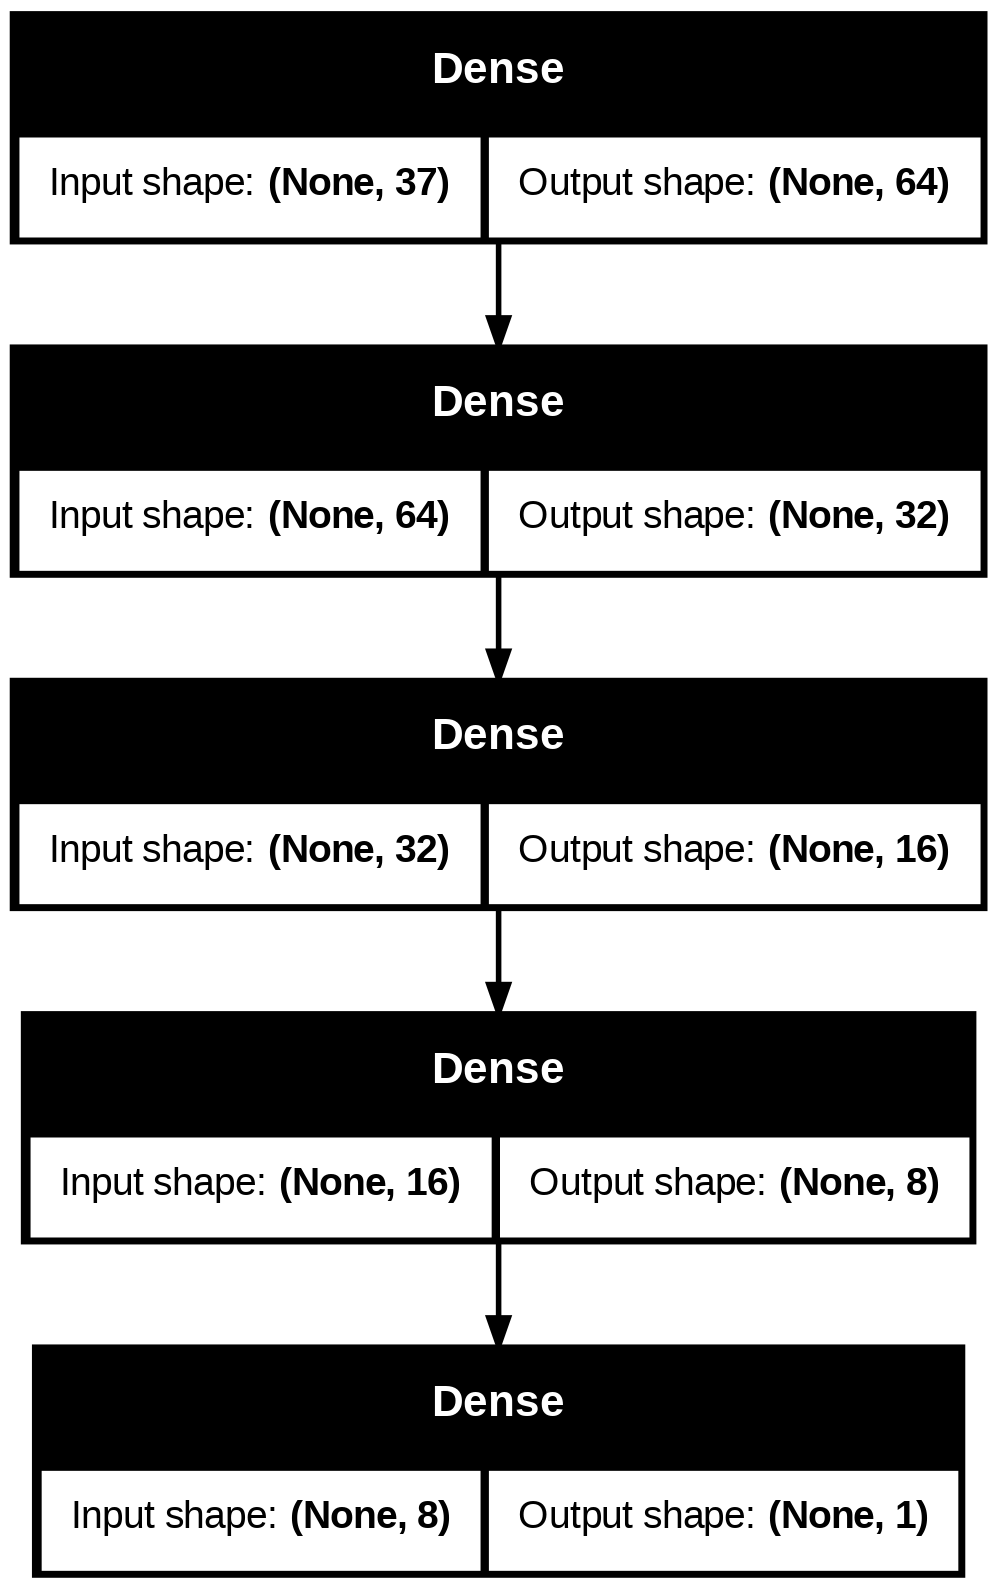

In [ ]:
# Plot layers

tf.keras.utils.plot_model(model, show_shapes=True)

In [ ]:
model.compile(loss='binary_crossentropy',
              optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
              metrics=['accuracy'])

In [ ]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 64)             │         2,432 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 8)              │           136 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 1)              │             9 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 5,185 (20.25 KB)

 Trainable params: 5,185 (20.25 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint

early_stopping = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True
)

model_checkpoint = ModelCheckpoint(
    'best_model.keras',
    monitor='val_loss',
    save_best_only=True
)

callbacks = [early_stopping, model_checkpoint]

# Training Model

In [ ]:
%%time

history = model.fit(
    X_train,
    y_train,
    validation_data=(X_val, y_val),
    epochs=100,
    batch_size=32,
    callbacks=callbacks,
    class_weight=class_weight_dict,
    verbose=1
)


Epoch 1/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 6s 24ms/step - accuracy: 0.3634 - loss: 0.7187 - val_accuracy: 0.5640 - val_loss: 0.6774
Epoch 2/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - accuracy: 0.6527 - loss: 0.6401 - val_accuracy: 0.6520 - val_loss: 0.6459
Epoch 3/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.7307 - loss: 0.5805 - val_accuracy: 0.7160 - val_loss: 0.6017
Epoch 4/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step - accuracy: 0.7718 - loss: 0.5246 - val_accuracy: 0.7120 - val_loss: 0.5676
Epoch 5/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.7938 - loss: 0.4733 - val_accuracy: 0.7400 - val_loss: 0.5416
Epoch 6/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 21ms/step - accuracy: 0.8238 - loss: 0.4248 - val_accuracy: 0.7560 - val_loss: 0.5173
Epoch 7/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step - accuracy: 0.8488 - loss: 0.3816 - val_accuracy: 0.7800 - val_loss: 0.4978
Epoch 8/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.8659 - loss: 0.3402 - val_accuracy: 0.7

# Training vs Validation

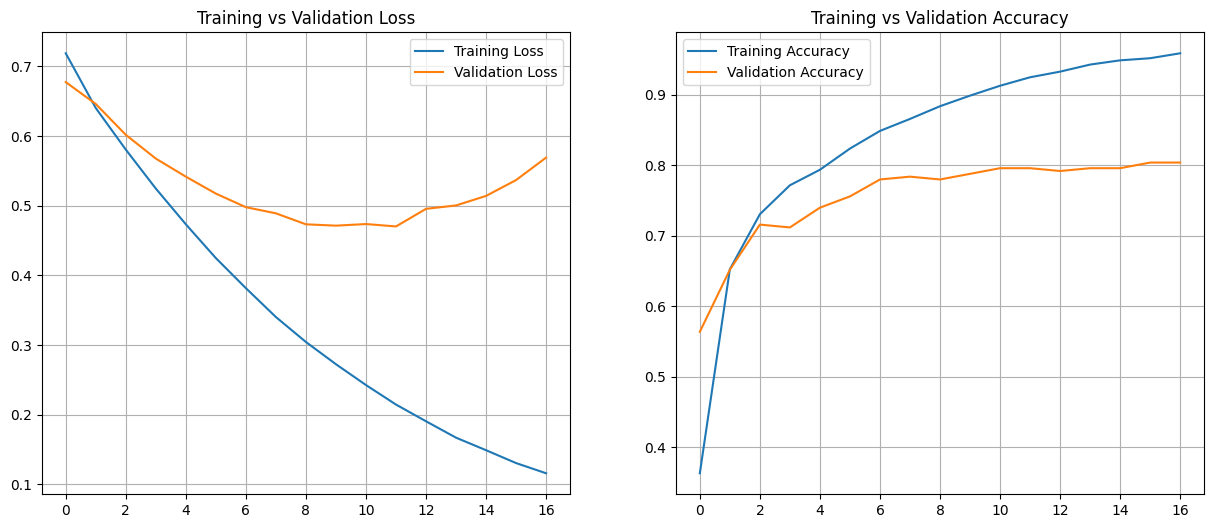

In [ ]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))

ax1.plot(history.history['loss'], label='Training Loss')
ax1.plot(history.history['val_loss'], label='Validation Loss')
ax1.grid()
ax1.set_title('Training vs Validation Loss')

ax2.plot(history.history['accuracy'], label='Training Accuracy')
ax2.plot(history.history['val_accuracy'], label='Validation Accuracy')
ax2.grid()
ax2.set_title('Training vs Validation Accuracy')

ax1.legend()
ax2.legend()

# Evaluasi Model

**Training vs Validation:**

1.  **Training Loss  vs Validation Loss:**
    *   **Training Loss:** Menunjukkan seberapa baik model Anda menyesuaikan diri dengan data yang telah dilihatnya (data pelatihan). Seharusnya nilai ini terus menurun seiring berjalannya epoch.
    *   **Validation Loss:** Menunjukkan seberapa baik model Anda melakukan generalisasi pada data baru yang belum pernah dilihatnya (data validasi). Ini adalah indikator yang lebih jujur tentang kinerja model di dunia nyata.
    *   **Interpretasi Plot Anda:** Dari plot di sel, terlihat bahwa Training Loss terus menurun, yang bagus. Namun, Validation Loss menurun pada awalnya kemudian mulai naik setelah beberapa epoch. Ini adalah tanda **overfitting**, di mana model Anda mulai terlalu menghafal data pelatihan dan kehilangan kemampuan untuk menggeneralisasi ke data baru. `EarlyStopping` yang Anda gunakan telah membantu menghentikan pelatihan sebelum overfitting menjadi terlalu parah.

2.  **Training Accuracy vs Validation Accuracy:**
    *   **Training Accuracy:** Seberapa akurat model pada data pelatihan. Seharusnya terus meningkat.
    *   **Validation Accuracy:** Seberapa akurat model pada data validasi. Ini adalah metrik utama untuk menilai kinerja generalisasi.
    *   **Interpretasi Plot Anda:** Mirip dengan loss, Training Accuracy Anda meningkat, tetapi Validation Accuracy cenderung stagnan atau sedikit menurun setelah beberapa epoch, menegaskan adanya overfitting ringan yang dideteksi oleh Validation Loss.

In [ ]:
y_pred_test = model.predict(X_test)
y_pred_test = (y_pred_test > 0.5).astype(int)

print(classification_report(y_test, y_pred_test))

7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step
              precision    recall  f1-score   support

           0       0.91      0.87      0.89       190
           1       0.36      0.45      0.40        31

    accuracy                           0.81       221
   macro avg       0.63      0.66      0.64       221
weighted avg       0.83      0.81      0.82       221



**Evaluasi Model (setelah Pelatihan):**

Setelah model selesai dilatih (atau dihentikan oleh `EarlyStopping`), kita perlu mengevaluasinya secara final menggunakan data uji (`X_test`, `y_test`) yang sama sekali belum pernah dilihat model selama pelatihan maupun validasi. Ini dilakukan di sel menggunakan `classification_report`:

`classification_report` memberikan gambaran menyeluruh tentang kinerja model pada tugas klasifikasi, termasuk metrik-metrik berikut:

*   **Precision (Presisi):** Untuk kelas tertentu, ini adalah rasio prediksi positif yang benar terhadap total prediksi positif. Dalam konteks Anda, untuk kelas '1' (Attrition), presisi 0.33 berarti hanya 33% dari semua prediksi 'Attrition' oleh model Anda yang sebenarnya benar.
*   **Recall (Sensitivitas/Cakupan):** Untuk kelas tertentu, ini adalah rasio prediksi positif yang benar terhadap total jumlah kasus aktual dalam kelas tersebut. Untuk kelas '1', recall 0.03 berarti model Anda hanya berhasil mengidentifikasi 3% dari semua karyawan yang *sebenarnya* akan mengalami Attrition. Ini sangat rendah.
*   **F1-Score:** Ini adalah rata-rata harmonik dari presisi dan recall. Ini adalah metrik yang baik ketika Anda memiliki distribusi kelas yang tidak seimbang (seperti di sini, di mana '0' jauh lebih banyak daripada '1'). F1-score yang rendah untuk kelas '1' (0.06) menunjukkan kinerja yang buruk.
*   **Support:** Jumlah kemunculan kelas tersebut dalam `y_test`.
*   **Accuracy (Akurasi):** Rasio prediksi yang benar secara keseluruhan. Akurasi 0.86 terlihat tinggi, tetapi ini bisa menyesatkan dalam kasus kelas yang tidak seimbang. Karena kelas '0' (No Attrition) mendominasi, model bisa mencapai akurasi tinggi hanya dengan selalu memprediksi '0'.

**Kesimpulan Evaluasi:**

Dari `classification_report`, terlihat bahwa model Anda sangat baik dalam memprediksi kelas '0' (tanpa Attrition) dengan presisi dan recall yang tinggi (0.86 dan 0.99). Namun, kinerja model pada kelas '1' (Attrition) sangat buruk, dengan presisi 0.33 dan recall hanya 0.03. Ini menunjukkan bahwa model Anda kesulitan untuk mengidentifikasi karyawan yang akan mengalami Attrition, yang merupakan masalah serius jika 'Attrition' adalah target utama yang ingin Anda prediksi. Mungkin Anda perlu mempertimbangkan teknik penanganan imbalance class (seperti oversampling, undersampling, atau menggunakan fungsi kerugian yang mempertimbangkan ketidakseimbangan kelas) untuk meningkatkan kinerja model pada kelas minoritas (Attrition).

# Save Pipeline dan Model

In [ ]:
# Save Pipeline

import pickle

with open('attrition_pipeline.pkl', 'wb') as file_1:
  pickle.dump(model, file_1)

In [ ]:
# Model summary

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 64)             │         2,432 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 8)              │           136 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 1)              │             9 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 15,557 (60.77 KB)

 Trainable params: 5,185 (20.25 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 10,372 (40.52 KB)

In [ ]:
# Save ANN model

model.save('attrition.keras', include_optimizer=True)